In [8]:
from util import go_to_project_root
go_to_project_root()

CWD cambiado a la raíz del proyecto: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/Homeworks


# Tarea 3: Aplicacion de test de raiz unitaria en Series de Tiempo

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from source.data.loaders import create_dataset
from source.fit import inference as testmodule
from source.display.hw import hw3 as plot_utils
from source.display.hw.hw1 import save_figure
plot_utils.configure_matplotlib_for_latex()

%load_ext autoreload
%autoreload 2

LaTeX está disponible y la configuración se ha aplicado.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Cargando los datos

El archivo `base_25.xls` contiene informacion mensual de: 
- $Y$: IMACEC , 
- $P$: IPC  
- $I$ Tasa de Politica Monetaria 

Considere las series cuya `::key` asociada al diccionario de datos se muestra a continuacion
- `p`: $\ln(P_t)$, 
- `y`: $\ln(Y_t)$, 
- `dtp`: $\Delta \ln(P_t)$, 
- `dty`: $\Delta \ln(Y_t)$, 
- `i`: $i_t = I_t/100$.
- `t`: periodo $t$

In [3]:
dataset = create_dataset('./data/base_25.xls', problem=6)

[INFO] ¡Datos cargados exitosamente!


✅ Figura guardada exitosamente en ./presentation/figures/hw3/series_raw.pdf


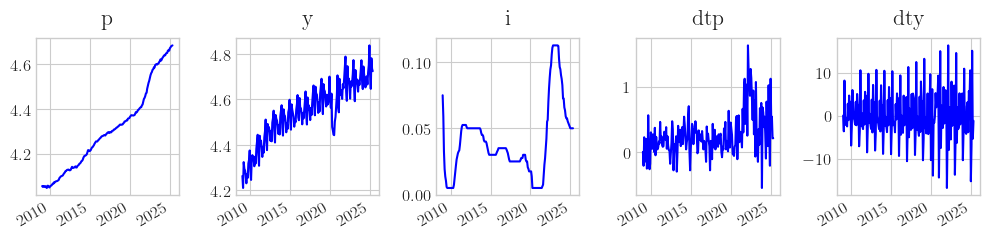

In [4]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=5, 
    figsize=(10, 2.5), 
)
fig, axes = plot_utils.plot_series(dataset, fig=fig, axes=axes)
save_figure(fig, './presentation/figures/hw3/series_raw.pdf')

## Test 1: DF (Dickey-Fuller)

In [5]:
df_se = {} 
df_se["p"] = testmodule.test_df(dataset["p"], estacionalizar = "si") 
df_se["y"] = testmodule.test_df(dataset["y"], estacionalizar = "si") 
df_se["i"] = testmodule.test_df(dataset["i"], estacionalizar = "si") 
df_se["dtp"] = testmodule.test_df(np.array(dataset["dtp"]), estacionalizar = "si") 
df_se["dty"] = testmodule.test_df(np.array(dataset["dty"]), estacionalizar = "si") 

df_ne = {} 
df_ne["p"] = testmodule.test_df(dataset["p"], estacionalizar = "no") 
df_ne["y"] = testmodule.test_df(dataset["y"], estacionalizar = "no") 
df_ne["i"] = testmodule.test_df(dataset["i"], estacionalizar = "no") 
df_ne["dtp"] = testmodule.test_df(np.array(dataset["dtp"]), estacionalizar = "no") 
df_ne["dty"] = testmodule.test_df(np.array(dataset["dty"]), estacionalizar = "no") 
df_ne['p']

,statistic,p-value
0,-0.693475,0.973573


## Test 2: ADF (Augmented Dickey-Fuller)

In [151]:
testmodule.test_adf(dataset['i'], max_k=50, model_type='c')

,model,statistic,p-value
0,ADF-c,-2.940563,0.047174


## Test 3: PP (Phillips-Perron)

In [198]:
df = testmodule.test_pp(dataset['p'])
df

,model,statistic,p-value
0,Sin constante ni tendencia,8.555829,1.0
1,Con constante,3.011328,1.0
2,Con constante y tendencia,-0.916815,1.0


## Test 4: KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

In [32]:
%%time
test_results=[]
for lab in ['y', 'p', 'dtp', 'dty', 'i']:
    try:
        out = testmodule.test_kpss(dataset[lab])
        out['variable'] = [lab]*out.shape[0]
        test_results.append(out)
    except Exception as e:
        print(e)
        continue

CPU times: user 28 ms, sys: 0 ns, total: 28 ms
Wall time: 27.2 ms


In [33]:
pd.concat(test_results)

,model,statistic,p-value,conclusion,variable
0,c,1.303613,0.10,No estacionaria,y
0,ct,0.189159,0.10,No estacionaria,y
0,c,1.360909,0.10,No estacionaria,p
0,ct,0.255009,0.10,No estacionaria,p
0,c,0.666459,0.10,No estacionaria,dtp
0,ct,0.076086,0.01,Estacionaria,dtp
0,c,0.049074,0.01,Estacionaria,dty
0,ct,0.037290,0.01,Estacionaria,dty
0,c,0.286387,0.01,Estacionaria,i
0,ct,0.128990,0.10,No estacionaria,i


## Test 5: Perron

✅ Figura guardada exitosamente en ./presentation/figures/hw3/breakpoints_fix.pdf


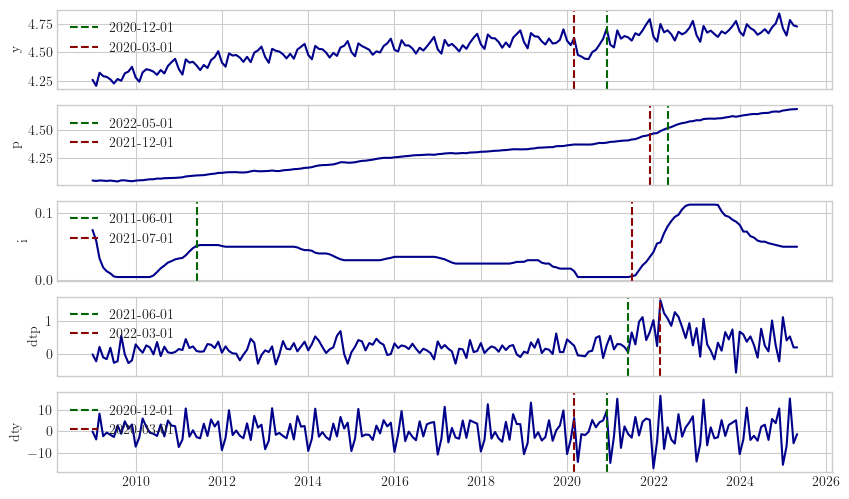

In [143]:
dataset['time'] = pd.to_datetime(dataset['t']) 
dataframe = pd.DataFrame(dataset)

bkpoints_B = [134, 155, 150, 158, 134]
bkpoints_A = [143, 160, 29, 149, 143]
fig, axes = plt.subplots(5, 1, figsize=(10, 6), sharex=True)
for i, keyna in enumerate(['y', 'p', 'i', 'dtp', 'dty']):
    axes[i].plot(dataset['t'], dataset[keyna], color="darkblue")
    axes[i].axvline(x=dataset['t'][bkpoints_A[i]], color='darkgreen', linestyle='--', 
                    label=dataframe['time'].dt.date[bkpoints_A[i]])
    
    axes[i].axvline(x=dataset['t'][bkpoints_B[i]], color='darkred', linestyle='--', 
                    label=dataframe['time'].dt.date[bkpoints_B[i]])
    axes[i].set_ylabel(keyna)
    axes[i].legend(loc='upper left')

save_figure(fig, './presentation/figures/hw3/breakpoints_fix.pdf')

In [144]:
%%time
test_results=[]
for bkkk in [bkpoints_A, bkpoints_B]:
    for k, lab in enumerate(['y', 'p', 'i', 'dtp', 'dty']):
        try:
            out = testmodule.test_perron(dataset[lab], varname=lab, breakpoint=bkkk[k])
            out['variable'] = [lab]*out.shape[0]
            out['order'] = [bkkk[k]]*out.shape[0]
            test_results.append(out)
        except Exception as e:
            print(e)
            continue

Test Perron
Test Perron
Test Perron
Test Perron
Test Perron
Test Perron
Test Perron
Test Perron
Test Perron
Test Perron
CPU times: user 2min 54s, sys: 294 ms, total: 2min 54s
Wall time: 39.3 s


In [145]:
final = pd.concat(test_results)
final['ss'] = [False]*len(final)
final['ss'][final['p-value']< 0.05]= True
final

,model,break,pstar,statistic,p-value,variable,order,ss
0,model_a,143,11,-2.721200,0.400326,y,143,False
0,model_b,143,0,-0.595990,0.990000,y,143,False
0,model_c,143,9,-0.224565,0.990000,y,143,False
0,model_a,160,48,-0.198863,0.990000,p,160,False
0,model_b,160,29,-0.674378,0.983307,p,160,False
0,model_c,160,29,-0.857086,0.980944,p,160,False
0,model_a,29,25,-1.100536,0.951180,i,29,False
0,model_b,29,0,-6.114782,0.010000,i,29,True
0,model_c,29,0,-6.130236,0.010000,i,29,True
0,model_a,149,50,-0.811783,0.977234,dtp,149,False


## Test 6: Zivot-Andrews

In [156]:
%%time
test_results=[]
for lab in ['y', 'p', 'dtp', 'dty', 'i']:
    try:
        out = testmodule.test_zivot_andrews_v2(dataset[lab], varname=lab)
        out['variable'] = [lab]*out.shape[0]
        test_results.append(out)
    except Exception as e:
        print(e)
        continue

Test Zivot-Andrews con statsmodels
Test Zivot-Andrews con statsmodels
Test Zivot-Andrews con statsmodels
Test Zivot-Andrews con statsmodels
Test Zivot-Andrews con statsmodels
CPU times: user 193 ms, sys: 1.01 ms, total: 194 ms
Wall time: 193 ms


In [157]:
final = pd.concat(test_results, axis=0)

✅ Figura guardada exitosamente en ./presentation/figures/hw3/breakpoints.pdf


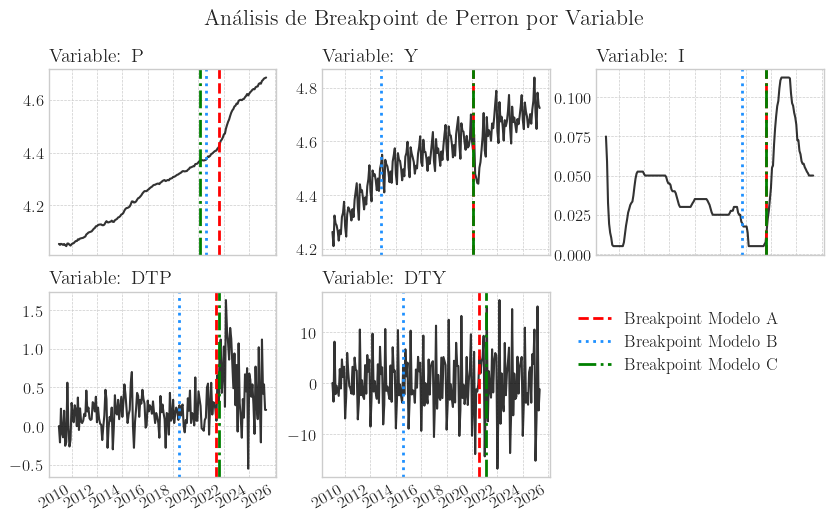

In [158]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=False)
axes = axes.flatten()
data_df = pd.DataFrame(dataset)
# 1. Asegúrate de que la columna de fecha sea del tipo datetime
data_df['t'] = pd.to_datetime(data_df['t'])

# 2. Establece esa columna como el índice del DataFrame
data_df.set_index('t', inplace=True)

fig, axes = plot_utils.plot_series_with_breakpoints( data_df,
                                        final,
                                        variables= ['p', 'y', 'i', 'dtp', 'dty'],
                                        fig=fig, axes=axes)
save_figure(fig, './presentation/figures/hw3/breakpoints.pdf')

In [154]:
import glob, os, re
model = 'model_a/y/'
ruta_carpeta = './presentation/backup/zivot_andrews/'+model
patron_busqueda = os.path.join(ruta_carpeta, "*.csv")
lista_archivos_csv = glob.glob(patron_busqueda)
regex = r'(\d+)(?=\.csv$)'
frames = []
for ruta_archivo in lista_archivos_csv:
    # re.search() busca el patrón en la cadena
    match = re.search(regex, ruta_archivo)
    if match:
        # El grupo 1 contiene el número capturado
        n = int(match.group(1))
        df_file = pd.read_csv(ruta_archivo)
        df_file['breakpoint'] = [n]*df_file.shape[0]
        frames.append(df_file)
frames = pd.concat(frames, axis=0)


Escala de color recortada al rango: [-2.94, 2.80]
Óptimo encontrado: HQC=-3.97 en p=1, breakpoint=131
✅ Figura guardada exitosamente en ./presentation/figures/hw3/best_p_model_a.pdf


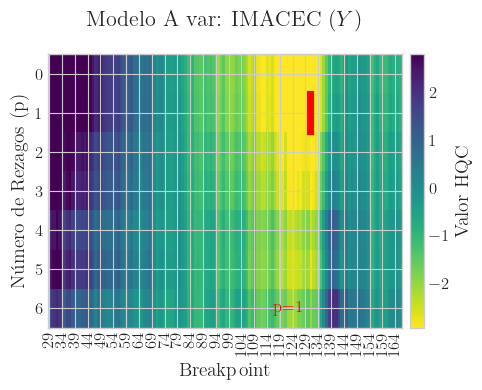

In [155]:
matriz_hqc = frames.pivot_table(
    index='p', 
    columns='breakpoint', 
    values='t'
)

titles = {
    'model_a/y/': 'Modelo A var: IMACEC ($Y$)',
    'model_b/y/': 'Modelo B var: IMACEC ($Y$)',
    'model_c/y/': 'Modelo C var: IMACEC ($Y$)',

    'model_a/i/': 'Modelo A var: TPM $(i)$',
    'model_b/i/': 'Modelo B var: TPM $(i)$',
    'model_c/i/': 'Modelo C var: TPM $(i)$',

    'model_a/p/': 'Modelo A var: Inflacion $(P)$',
    'model_b/p/': 'Modelo B var: Inflacion $(P)$',
    'model_c/p/': 'Modelo C var: Inflacion $(P)$'
}
fig, ax = plt.subplots(1, 1, figsize=(5,4))
fig, ax = plot_utils.plot_hqc_heatmap(matriz_hqc, 
                                      fig=fig, 
                                      ax=ax, 
                                      title=titles[model], 
                                      quantile_clip=(0.05, 0.95))
save_figure(fig, './presentation/figures/hw3/best_p_{}.pdf'.format(model.split('/')[0]))

## Test 7: Bierens

In [173]:
testmodule.test_bierens(dataset['y'], max_k=5, max_m=20)

,model,statistic,p-value
0,"Bierens(m=1, k=5)",-51.517432,0.01


## Test 8: Murray and Nelson

In [15]:
murray_nelson = {} 
murray_nelson["p"] = testmodule.test_murray_nelson(dataset["p"], periodos=[7,68,157], persistente=152) 
murray_nelson["y"] = testmodule.test_murray_nelson(dataset["y"], periodos=[25,145,155], persistente=135) 
murray_nelson["i"] = testmodule.test_murray_nelson(dataset["i"], periodos=[0,1,2], persistente=150) 
murray_nelson["dtp"] = testmodule.test_murray_nelson(np.array(dataset["dtp"]), periodos=[157,178,191], persistente=152) 
murray_nelson["dty"] = testmodule.test_murray_nelson(np.array(dataset["dty"]), periodos=[191,158,143,146,155]) 
murray_nelson["p"]

,statistic,p-value
0,-6.815129,3.685725e-08


## Test 9: GLS detrending

In [183]:
dataset['p'].shape

(197,)

In [181]:
testmodule.test_gls(dataset['p'], d=3, p=13, alpha=0.05)

ValueError: could not broadcast input array from shape (195,) into shape (196,)